In [1]:
%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'

## Instalación de algunos paquetes.
!apt-get update
## Para usar gymnasium[box2d]
!apt install swig
!pip install gymnasium[box2d]

In [2]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym

In [3]:
name = 'FrozenLake-v1'
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi") # No resbaladizo para entender mejor los resultados.
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi") # No resbaladizo para entender mejor los resultados.

In [4]:
# actions
LEFT, DOWN, RIGHT, UP = 0,1,2,3

# Política epsilon-soft. Se usa para el entrenamiento
def random_epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = np.ones(nA, dtype=float) * epsilon / nA
    best_action = np.argmax(Q[state])
    pi_A[best_action] += (1.0 - epsilon)
    return pi_A

# Política epsilon-greedy a partir de una epsilon-soft
def epsilon_greedy_policy(Q, epsilon, state, nA):
    pi_A = random_epsilon_greedy_policy(Q, epsilon, state, nA)
    return np.random.choice(np.arange(nA), p=pi_A)

# Política Greedy a partir de los valones Q. Se usa para mostrar la solución.
def pi_star_from_Q(env, Q):
    done = False
    pi_star = np.zeros([env.observation_space.n, env.action_space.n])
    state, info = env.reset() # start in top-left, = 0
    actions = ""
    while not done:
        action = np.argmax(Q[state, :])
        actions += f"{action}, "
        pi_star[state,action] = action
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    return pi_star, actions

In [5]:
def plot_frozen_lake(env):
    """
    Crea una representación gráfica del entorno FrozenLake usando gymnasium.
    Utiliza colores y formas geométricas en lugar de emojis.
    """
    # Obtener el mapa del entorno
    lake_map = np.array(env.unwrapped.desc, dtype=str)
    nrows, ncols = lake_map.shape

    # Crear la figura
    fig, ax = plt.subplots(figsize=(ncols, nrows))
    ax.set_xticks(np.arange(ncols))
    ax.set_yticks(np.arange(nrows))
    ax.grid(which="both", color="black", linestyle='-', linewidth=1)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

    # Definir colores y formas para cada tipo de celda
    cell_styles = {
        'S': {'color': 'blue', 'label': 'Inicio'},    # Inicio
        'F': {'color': 'lightblue', 'label': 'Hielo'},  # Hielo
        'H': {'color': 'black', 'label': 'Hoyo'},   # Agujero
        'G': {'color': 'gold', 'label': 'Meta'},    # Meta
    }

    # Dibujar el mapa
    for i in range(nrows):
        for j in range(ncols):
            cell = lake_map[i, j]
            style = cell_styles[cell]
            ax.add_patch(plt.Rectangle((j, nrows - i - 1), 1, 1, color=style['color']))
            ax.text(j + 0.5, nrows - i - 0.5, style['label'], ha='center', va='center', fontsize=12, color='white' if cell in ['H', 'S'] else 'black')

    # Configurar límites y aspecto
    ax.set_xlim(0, ncols)
    ax.set_ylim(0, nrows)
    ax.set_aspect('equal')

    plt.title("FrozenLake Environment", fontsize=16, pad=20)
    plt.show()

In [6]:
def plot(list_stats):
  # Creamos una lista de índices para el eje x
  indices = list(range(len(list_stats)))

  # Creamos el gráfico
  plt.figure(figsize=(6, 3))
  plt.plot(indices, list_stats)

  # Añadimos título y etiquetas
  plt.title('Proporción de recompensas')
  plt.xlabel('Episodio')
  plt.ylabel('Proporción')

  # Mostramos el gráfico
  plt.grid(True)
  plt.show()

# Define la función para mostrar el tamaño de los episodios
import numpy as np
import matplotlib.pyplot as plt

def plot_episode_lengths(list_lengths):
    indices = np.arange(len(list_lengths))

    plt.figure(figsize=(8, 4))
    plt.plot(indices, list_lengths, label="Longitud del episodio", alpha=0.7)

    # Ajuste de curva de tendencia (suavizado con media móvil)
    window = max(1, len(list_lengths) // 50)  # Ventana del suavizado
    trend = np.convolve(list_lengths, np.ones(window)/window, mode='valid')
    plt.plot(np.arange(len(trend)), trend, label="Curva de tendencia", color="red", linewidth=2)

    plt.title("Longitud de episodios por estado")
    plt.xlabel("Episodio")
    plt.ylabel("Longitud")
    plt.legend()
    plt.grid(True)
    plt.show()

In [7]:
import os
import gc
import torch
import numpy as np
import gymnasium as gym
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda")
print(f"Usando dispositivo: {device}")
# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU
# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla
# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python
# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad
# Fijar la semilla en Gymnasium
def make_env(env_name):
    env = gym.make(env_name)
    env.reset(seed=seed) # Establece la semilla en el entorno de Gymnasium
    return env
# Ejemplo de creación de un entorno con semilla
env_name = "CartPole-v1" # Cambiar según el entorno deseado
env = make_env(env_name)

Usando dispositivo: cuda


## OFF POLICY

In [8]:
def monte_carlo_control_off_policy(env, num_episodes=5000, epsilon=0.4, decay=False, discount_factor=1):
    """
    Algoritmo de Monte Carlo Off-Policy.

    Parámetros:
    - env: Entorno de Gym.
    - num_episodes: Número de episodios para entrenar.
    - epsilon: Probabilidad de exploración en la política de comportamiento.
    - decay: Si True, decae epsilon con el tiempo.
    - discount_factor: Factor de descuento.

    Retorna:
    - Q: La función de valor acción-estado aprendida.
    - list_stats: Lista de recompensas promedio acumuladas.
    - episode_lengths: Lista de longitudes de los episodios.
    """
    nA = env.action_space.n
    Q = np.zeros([env.observation_space.n, nA])
    C = np.zeros([env.observation_space.n, nA])  # Suma acumulada de ratios de importancia
    episode_lengths = []
    list_stats = []
    total_reward = 0

    step_display = num_episodes // 10  # Cada cuántos episodios mostrar progreso

    for episode in tqdm(range(num_episodes)):  # Barra de progreso
        state, _ = env.reset()  # Extraer solo el estado, ignorar el diccionario de información
        done = False
        episode_data = []
        steps = 0
        episode_reward = 0

        # Generar episodio completo siguiendo la política de comportamiento
        while not done:
            if decay:
                epsilon = min(1.0, 1000.0 / (episode + 1))
            action = epsilon_greedy_policy(Q, epsilon, state, nA)
            new_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_data.append((state, action, reward))
            state = new_state
            steps += 1
            episode_reward += reward

        episode_lengths.append(steps)
        total_reward += episode_reward
        list_stats.append(total_reward / (episode + 1))

        # Calcular retornos y ratios de importancia
        G = 0
        W = 1  # Peso acumulado (ratio de importancia)
        for t in reversed(range(len(episode_data))):
            state, action, reward = episode_data[t]
            G = reward + discount_factor * G
            C[state, action] += W
            Q[state, action] += (W / C[state, action]) * (G - Q[state, action])

            # Actualizar el peso acumulado
            if action != np.argmax(Q[state]):
                break  # Si la acción no es la de la política objetivo, descartar el resto del episodio
            W = W * 1.0 / (1 - epsilon + epsilon / nA)

        # Mostrar progreso cada cierto número de episodios
        if episode % step_display == 0 and episode > 0:
            print(f"Episodio {episode}/{num_episodes} - Recompensa Promedio: {list_stats[-1]:.3f}")

    return Q, list_stats, episode_lengths

In [9]:
Q, list_stats, episode_lengths = monte_carlo_control_off_policy(env4, num_episodes=50000, epsilon=0.9, decay = True)

 11%|█         | 5463/50000 [00:01<00:17, 2559.97it/s]

Episodio 5000/50000 - Recompensa Promedio: 0.184


 22%|██▏       | 10805/50000 [00:03<00:10, 3909.79it/s]

Episodio 10000/50000 - Recompensa Promedio: 0.344


 31%|███▏      | 15632/50000 [00:04<00:07, 4851.39it/s]

...

 82%|████████▏ | 40952/50000 [00:09<00:01, 4796.98it/s]

Episodio 40000/50000 - Recompensa Promedio: 0.800


 91%|█████████▏| 45744/50000 [00:10<00:00, 4806.98it/s]

Episodio 45000/50000 - Recompensa Promedio: 0.820


100%|██████████| 50000/50000 [00:11<00:00, 4208.02it/s]


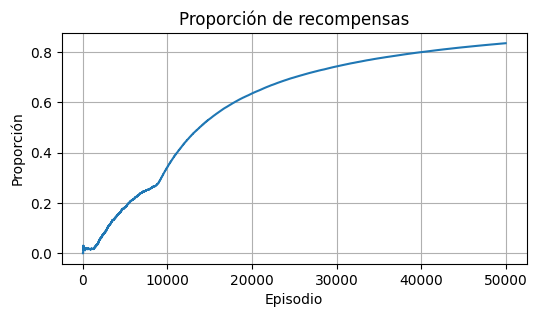

Máxima proporcion: 0.8356


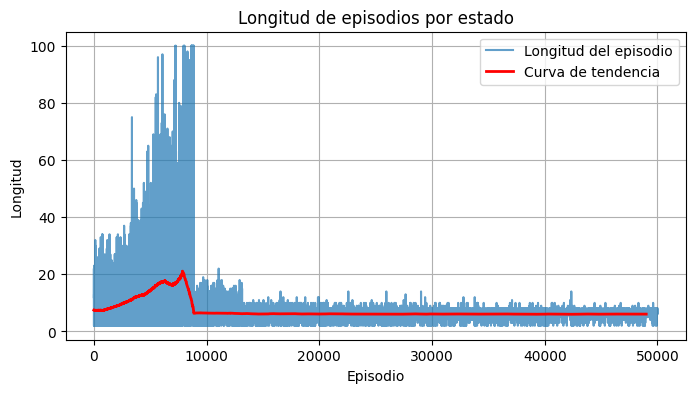

In [10]:
plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")
plot_episode_lengths(episode_lengths);

## SARSA

In [11]:
def sarsa_control(env, num_episodes=5000, epsilon=0.4, decay=False, discount_factor=1.0, alpha=0.1):
    """
    Algoritmo SARSA (on-policy).

    Parámetros:
    - env: Entorno de Gym.
    - num_episodes: Número de episodios para entrenar.
    - epsilon: Probabilidad de exploración en la política epsilon-greedy.
    - decay: Si True, decae epsilon con el tiempo.
    - discount_factor: Factor de descuento.
    - alpha: Tasa de aprendizaje.

    Retorna:
    - Q: La función de valor acción-estado aprendida.
    - list_stats: Lista de recompensas promedio acumuladas.
    - episode_lengths: Lista de longitudes de los episodios.
    """
    nA = env.action_space.n
    Q = np.zeros([env.observation_space.n, nA])  # Inicializar Q(s, a)
    episode_lengths = []
    list_stats = []
    total_reward = 0

    step_display = num_episodes // 10  # Cada cuántos episodios mostrar progreso

    for episode in tqdm(range(num_episodes)):  # Barra de progreso
        state, _ = env.reset()  # Reiniciar el entorno y obtener el estado inicial
        done = False
        steps = 0
        episode_reward = 0

        # Elegir la acción inicial usando la política epsilon-greedy
        action = epsilon_greedy_policy(Q, epsilon, state, nA)

        while not done:
            # Tomar la acción y observar el próximo estado y la recompensa
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Elegir la siguiente acción usando la política epsilon-greedy
            next_action = epsilon_greedy_policy(Q, epsilon, next_state, nA)

            # Actualizar Q(s, a) usando la regla de SARSA
            Q[state, action] += alpha * (reward + discount_factor * Q[next_state, next_action] - Q[state, action])

            # Actualizar el estado y la acción
            state = next_state
            action = next_action

            # Contabilizar pasos y recompensas
            steps += 1
            episode_reward += reward

        # Guardar estadísticas del episodio
        episode_lengths.append(steps)
        total_reward += episode_reward
        list_stats.append(total_reward / (episode + 1))

        # Decaimiento de epsilon (si está habilitado)
        if decay:
            epsilon = min(1.0, 1000.0 / (episode + 1))

        # Mostrar progreso cada cierto número de episodios
        if episode % step_display == 0 and episode > 0:
            print(f"Episodio {episode}/{num_episodes} - Recompensa Promedio: {list_stats[-1]:.3f}")

    return Q, list_stats, episode_lengths

In [12]:
Q, list_stats, episode_lengths = sarsa_control(env4, num_episodes=100000, epsilon=0.5, decay=True, discount_factor=0.99, alpha=0.1)

 11%|█         | 10568/100000 [00:02<00:22, 3974.99it/s]

Episodio 10000/100000 - Recompensa Promedio: 0.622


 20%|██        | 20464/100000 [00:05<00:22, 3564.35it/s]

Episodio 20000/100000 - Recompensa Promedio: 0.772


 30%|███       | 30472/100000 [00:07<00:16, 4090.25it/s]

...

 81%|████████  | 80900/100000 [00:19<00:04, 4495.56it/s]

Episodio 80000/100000 - Recompensa Promedio: 0.921


 91%|█████████ | 90570/100000 [00:21<00:02, 4698.43it/s]

Episodio 90000/100000 - Recompensa Promedio: 0.928


100%|██████████| 100000/100000 [00:23<00:00, 4279.14it/s]


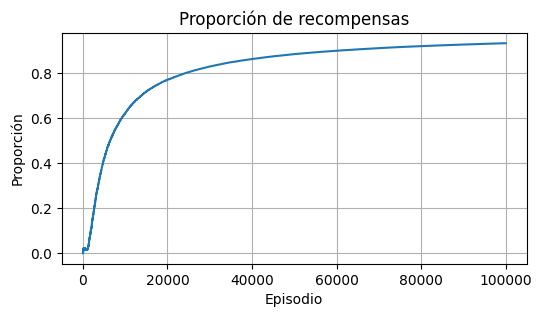

Máxima proporcion: 0.9341


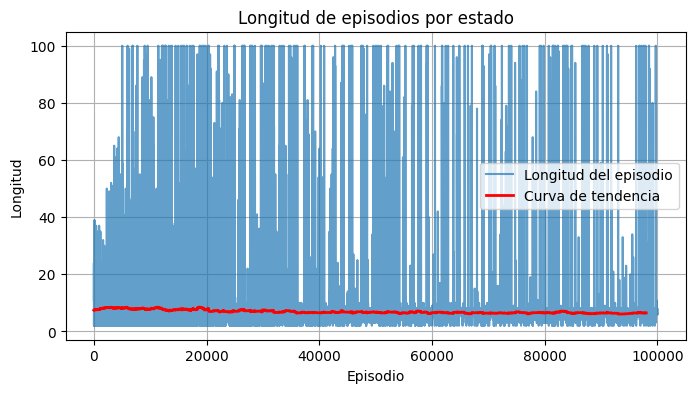

In [13]:
plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

plot_episode_lengths(episode_lengths);

In [14]:
# @title Política final
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = pi_star_from_Q(env4, Q)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())
print()

Política óptima obtenida
 [[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones 1, 1, 2, 1, 2, 2,  
 Para el siguiente grid
   (Right)
SFFF
FHFH
FFFH
HFFG




## Q LEARNING

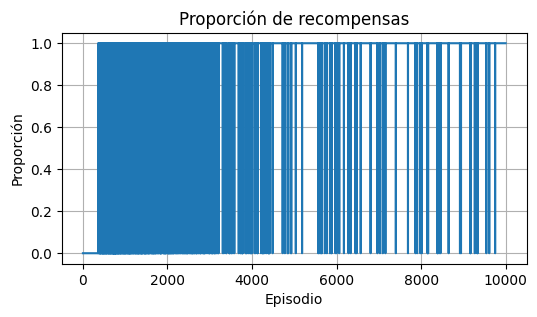

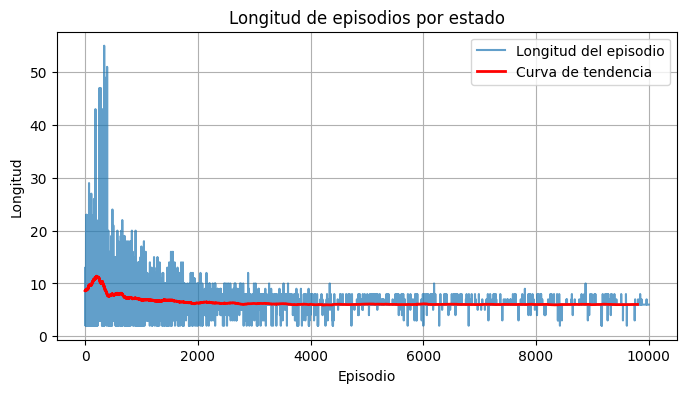

In [15]:
import gymnasium as gym
import numpy as np
import random
import time

# Initialize the environment
env = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi") # No resbaladizo para entender mejor los resultados.
action_space_size = env.action_space.n
state_space_size = env.observation_space.n

q_table = np.zeros((state_space_size, action_space_size))

# Define the hyperparameters
num_episodes = 10000
max_steps_per_episode = 100
learning_rate = 0.1
discount_rate = 0.99
exploration_rate = 1
max_exploration_rate = 1
min_exploration_rate = 0.01
exploration_decay_rate = 0.001

# Initialize lists to keep track of rewards and episode lengths
all_rewards = []
episode_lengths = []

# Implement the Q-learning algorithm
for episode in range(num_episodes):
    state = env.reset()[0]
    done = False
    rewards_current_episode = 0
    episode_length = 0

    for step in range(max_steps_per_episode):
        exploration_rate_threshold = random.uniform(0, 1)
        if exploration_rate_threshold > exploration_rate:
            action = np.argmax(q_table[state, :])
        else:
            action = env.action_space.sample()

        new_state, reward, done, _, _ = env.step(action)

        q_table[state, action] = q_table[state, action] * (1 - learning_rate) + \
                                 learning_rate * (reward + discount_rate * np.max(q_table[new_state, :]))

        state = new_state
        rewards_current_episode += reward
        episode_length += 1

        if done:
            break

    all_rewards.append(rewards_current_episode)
    episode_lengths.append(episode_length)

    exploration_rate = min_exploration_rate + \
                       (max_exploration_rate - min_exploration_rate) * np.exp(-exploration_decay_rate * episode)

# Plot proportion of rewards
plot(all_rewards)

# Plot episode lengths
plot_episode_lengths(episode_lengths)

## SARSA SEMI GRADIENTE

In [16]:
# Función para extraer características del estado (feature vector)
def feature_vector(state, action, nA):
    """
    Crea un vector de características para el par (estado, acción).
    """
    features = np.zeros((nA, len(state)))  # nA acciones y len(state) características por acción
    features[action, :] = state  # Solo las características de la acción seleccionada son no cero
    return features.flatten()

# Política epsilon-soft. Se usa para el entrenamiento
def random_epsilon_greedy_policy(Q_weights, epsilon, state, nA):
    """
    Política epsilon-soft basada en los pesos de Q.
    """
    q_values = [np.dot(Q_weights, feature_vector(state, a, nA)) for a in range(nA)]
    best_action = np.argmax(q_values)
    pi_A = np.ones(nA, dtype=float) * epsilon / nA
    pi_A[best_action] += (1.0 - epsilon)
    return pi_A

# Política epsilon-greedy a partir de una epsilon-soft
def epsilon_greedy_policy(Q_weights, epsilon, state, nA):
    """
    Política epsilon-greedy basada en los pesos de Q.
    """
    pi_A = random_epsilon_greedy_policy(Q_weights, epsilon, state, nA)
    return np.random.choice(np.arange(nA), p=pi_A)

def sarsa_semi_gradient(env, num_episodes=5000, epsilon=0.1, decay=False, discount_factor=0.99, alpha=0.01):
    """
    Algoritmo SARSA semi-gradiente.

    Parámetros:
    - env: Entorno de Gym.
    - num_episodes: Número de episodios para entrenar.
    - epsilon: Probabilidad de exploración en la política epsilon-greedy.
    - decay: Si True, decae epsilon con el tiempo.
    - discount_factor: Factor de descuento.
    - alpha: Tasa de aprendizaje.

    Retorna:
    - Q_weights: Pesos de la función de valor Q.
    - list_stats: Lista de recompensas promedio acumuladas.
    - episode_lengths: Lista de longitudes de los episodios.
    """
    nA = env.action_space.n
    state_dim = env.observation_space.shape[0]
    Q_weights = np.zeros(nA * state_dim)  # Pesos para la función Q (nA * state_dim)
    episode_lengths = []
    list_stats = []
    total_reward = 0

    for episode in tqdm(range(num_episodes)):  # Barra de progreso
        state, _ = env.reset()
        done = False
        steps = 0
        episode_reward = 0

        # Elegir la acción inicial usando la política epsilon-greedy
        action = epsilon_greedy_policy(Q_weights, epsilon, state, nA)

        while not done:
            # Tomar la acción y observar el próximo estado y la recompensa
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Elegir la siguiente acción usando la política epsilon-greedy
            next_action = epsilon_greedy_policy(Q_weights, epsilon, next_state, nA)

            # Calcular el error TD
            q_current = np.dot(Q_weights, feature_vector(state, action, nA))
            q_next = np.dot(Q_weights, feature_vector(next_state, next_action, nA))
            td_error = reward + discount_factor * q_next - q_current

            # Actualizar los pesos usando el gradiente semi-gradiente
            Q_weights += alpha * td_error * feature_vector(state, action, nA)

            # Actualizar el estado y la acción
            state = next_state
            action = next_action

            # Contabilizar pasos y recompensas
            steps += 1
            episode_reward += reward

        # Guardar estadísticas del episodio
        episode_lengths.append(steps)
        total_reward += episode_reward
        list_stats.append(total_reward / (episode + 1))

        # Decaimiento de epsilon (si está habilitado)
        if decay:
            epsilon = min(1.0, 1000.0 / (episode + 1))

    return Q_weights, list_stats, episode_lengths

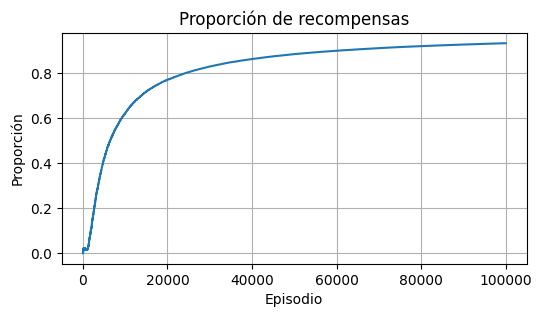

Máxima proporcion: 0.9341


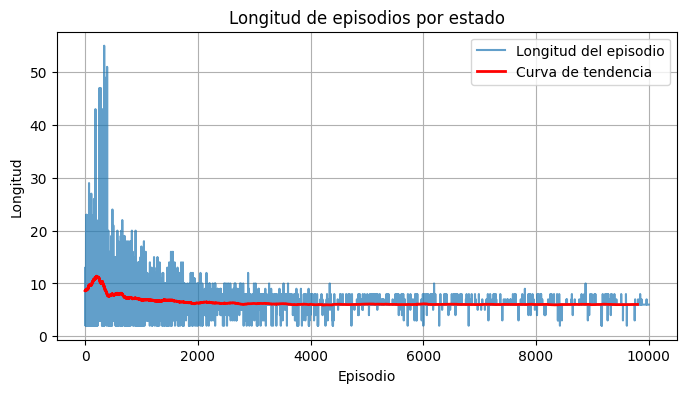

In [17]:
plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

plot_episode_lengths(episode_lengths);

## DEEP Q LEARNING

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

# Definir la red neuronal para aproximar Q(s, a)
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, state):
        x = torch.relu(self.fc1(state))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

def deep_q_learning(env, num_episodes=1000, epsilon=0.1, decay=False, discount_factor=0.99, alpha=0.001, batch_size=64, memory_size=10000):
    """
    Algoritmo Deep Q-Learning (DQN).

    Parámetros:
    - env: Entorno de Gym.
    - num_episodes: Número de episodios para entrenar.
    - epsilon: Probabilidad de exploración en la política epsilon-greedy.
    - decay: Si True, decae epsilon con el tiempo.
    - discount_factor: Factor de descuento.
    - alpha: Tasa de aprendizaje.
    - batch_size: Tamaño del batch para el replay.
    - memory_size: Tamaño de la memoria de replay.

    Retorna:
    - policy_net: Red neuronal entrenada.
    - list_stats: Lista de recompensas promedio acumuladas.
    - episode_lengths: Lista de longitudes de los episodios.
    """
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Red neuronal y optimizador
    policy_net = DQN(state_dim, action_dim)
    target_net = DQN(state_dim, action_dim)
    target_net.load_state_dict(policy_net.state_dict())
    optimizer = optim.Adam(policy_net.parameters(), lr=alpha)

    # Memoria de replay
    memory = deque(maxlen=memory_size)

    episode_lengths = []
    list_stats = []
    total_reward = 0

    for episode in tqdm(range(num_episodes)):  # Barra de progreso
        state, _ = env.reset()
        done = False
        steps = 0
        episode_reward = 0

        while not done:
            # Elegir la acción usando la política epsilon-greedy
            if np.random.rand() < epsilon:
                action = env.action_space.sample()  # Exploración
            else:
                with torch.no_grad():
                    q_values = policy_net(torch.FloatTensor(state))
                    action = torch.argmax(q_values).item()  # Explotación

            # Tomar la acción y observar el próximo estado y la recompensa
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Guardar la transición en la memoria de replay
            memory.append((state, action, reward, next_state, done))

            # Actualizar el estado
            state = next_state

            # Contabilizar pasos y recompensas
            steps += 1
            episode_reward += reward

            # Entrenar la red neuronal con un batch de la memoria de replay
            if len(memory) >= batch_size:
                batch = random.sample(memory, batch_size)
                states, actions, rewards, next_states, dones = zip(*batch)

                states = torch.FloatTensor(states)
                actions = torch.LongTensor(actions)
                rewards = torch.FloatTensor(rewards)
                next_states = torch.FloatTensor(next_states)
                dones = torch.FloatTensor(dones)

                # Calcular los Q-valores actuales
                q_values = policy_net(states).gather(1, actions.unsqueeze(1))

                # Calcular los Q-valores objetivo
                with torch.no_grad():
                    next_q_values = target_net(next_states).max(1)[0]
                    target_q_values = rewards + discount_factor * next_q_values * (1 - dones)

                # Calcular la pérdida y actualizar la red
                loss = nn.MSELoss()(q_values.squeeze(), target_q_values)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Actualizar la red objetivo
        if episode % 10 == 0:
            target_net.load_state_dict(policy_net.state_dict())

        # Guardar estadísticas del episodio
        episode_lengths.append(steps)
        total_reward += episode_reward
        list_stats.append(total_reward / (episode + 1))

        # Decaimiento de epsilon (si está habilitado)
        if decay:
            epsilon = min(1.0, 1000.0 / (episode + 1))

    return policy_net, list_stats, episode_lengths

  0%|          | 0/10000 [00:00<?, ?it/s]C:\Users\Carlos\AppData\Local\Temp\ipykernel_26044\1612575205.py:89: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  states = torch.FloatTensor(states)
100%|██████████| 10000/10000 [21:00<00:00,  7.93it/s]


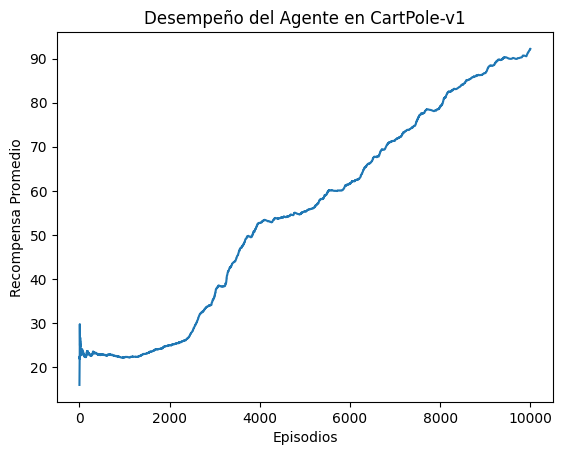

In [19]:
env = gym.make("CartPole-v1")

# Entrenar la red neuronal con DQN
policy_net, list_stats, episode_lengths = deep_q_learning(
    env,
    num_episodes=10000,  # Puedes aumentar para mejor entrenamiento
    epsilon=0.6,
    decay=True,
    discount_factor=0.99,
    alpha=0.001,
    batch_size=64,
    memory_size=10000
)

# Cerrar el entorno
env.close()

# Mostrar resultados del entrenamiento
import matplotlib.pyplot as plt

plt.plot(list_stats)
plt.xlabel("Episodios")
plt.ylabel("Recompensa Promedio")
plt.title("Desempeño del Agente en CartPole-v1")
plt.show()